In [1]:
%%javascript
IPython.OutputArea.prototype._should_scroll = function(lines) {
    return false;
}

<IPython.core.display.Javascript object>

In [2]:
# Import libraries and setup matplotlib defaults
from matplotlib import pyplot as pl
import pandas as pd
import numpy as np
pl.style.use('bmh')
clist = ['#377eb8', '#e41a1c', '#4daf4a', '#984ea3', '#ff7f00',
         '#ffff33', '#a65628', '#f781bf', '#999999']
prop_cycle = pl.cycler(color=clist)
pl.rcParams.update({
    'axes.prop_cycle': prop_cycle,
    'lines.linewidth': 2,
    'font.size': 20,
    'figure.figsize': [12, 8],
    'figure.subplot.left': 0.125,
    'figure.subplot.right': 0.95,
    'figure.subplot.bottom': 0.15})

def text_search_plot(search, title_str, leg_loc=None, spacer=' ', group='year', filename=None):
    if 'top_user' not in search.keys():
        search.update({'top_user': 'true'})
    result = text_search(talk_data, search, group=group, spacer=spacer, quiet=True, norm='date')
    #fig, ax = pl.subplots()
    #result.plot(ax=ax, legend=False)
    result.plot(title=title_str,
                #ylabel='references per million words',
                xlabel='year',
                ylim=[0, None],
               )
    #pl.legend(result.columns, loc=leg_loc)
    #pl.grid(axis='x')

In [3]:
%%capture

# set up path to include parent directory
import sys
sys.path.append('../')

# Import everything from the data_utils library
from data_utils import *

# Load the data
apostle_data = load_apostle_data()
talk_data = get_only_talks(load_data())

# Create new date groups for 2 and 5 years at a time
#talk_data['2y'] = pd.to_datetime(
#    talk_data['date'].dt.year//2*20000+10101, format='%Y%m%d', utc=True)
#talk_data['5y'] = pd.to_datetime(
#    talk_data['date'].dt.year//5*50000+20701, format='%Y%m%d', utc=True)

It has been noted that the recently concluded general conference marks the 30th anniversary of the publication of the document formally titled "The Family: A Proclamation to the World". This proclamation has been much discussed ever since, including in general conference talks. To analyze the effect of the proclamation on church discourse, the plot below shows the number of uses per year of the word "proclamation" in all general conference talks, going back to the 1940s. The release of the proclamation in 1995 clearly had an impact, as the word suddenly came to be much more frequently used. Since 1942, the earliest year for which full text data of talks were available, 2/3 of all references to the word have occurred since 1995.

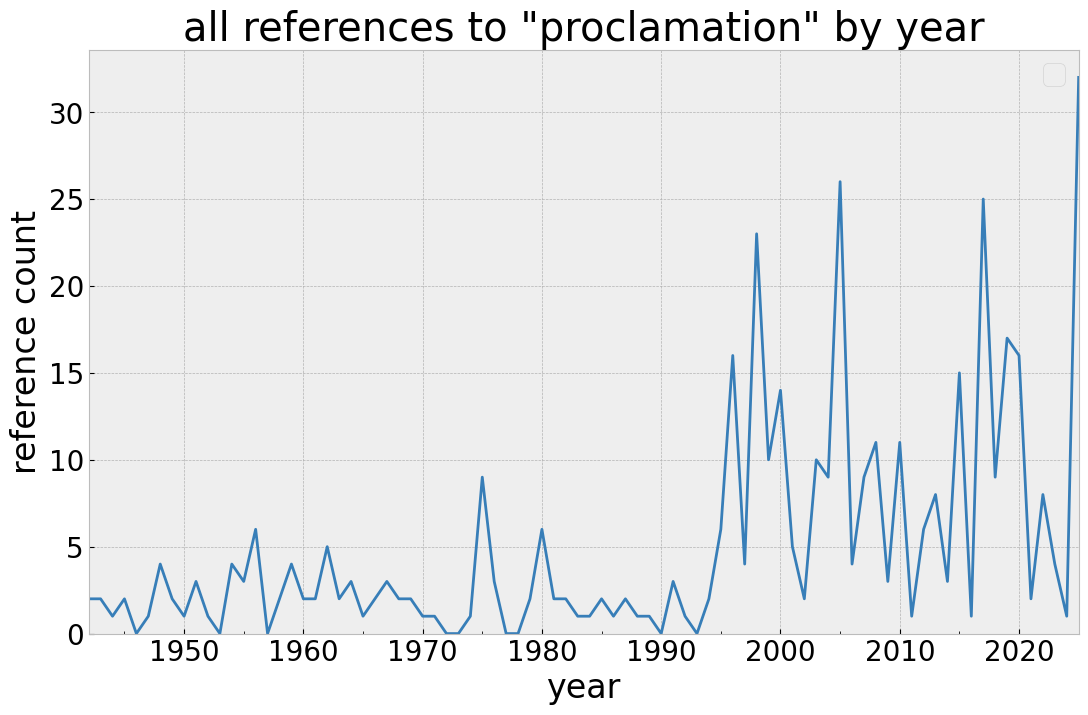

In [4]:
text_search_plot(
    {"search": [{"include": 'proclamation'}],
     "top_user": 'false'},
    'all references to "proclamation" by year', group='year')
pl.gca().legend([])
_ = pl.gca().set_ylabel('reference count')

## Analysis methodology
In order to understand and analyze more directly references to the family proclamation, we can't simply look at all uses of the word since October of 1995. Primarily this is because an additional proclamation was issued in 2020 in honor of the 200th anniversary of the First Vision, sometimes referred to as the "bicentennial proclamation". It is also difficult to isolate refereces specific to the family proclamation using neighboring words because it gets referred to in different ways, by its formal title, or often more informally as either the "family proclamation" or "proclamation on the family". After reviewing some of the references to the word "proclamation" in the last 30 years, it became apparent that there are many other usages of the word "proclamation" that are clearly referring specifically to the family proclamation. It also became apparent that a handful of talks in 2020 were clearly referring to the bicentennial proclamation, and that every other case reviewed was clearly referring to the family proclamation.

Based on this, the simplest solution, though not guaranteed to be perfectly accurate, was to filter out the 4 talks that referred to the bicentennial proclamation, and count all other references since 1995 to the word "proclamation" as references to the family proclamation for purposes of this analysis.

## Analysis of proclamation references
Applying this methodology, there appear to be a total of 204 references to the family proclamation in the last 30 years. In talks that mention the proclamation, most only mention it once, but a handful of talks have the proclamation as the entire focus of the talk, mentioning it many times. The record comes from the recent October 2025 general conference, in which Elder Ronald Rasband made reference to the proclamation a whopping 26 times!

In [5]:
talk_data_fam_proc_era = talk_data[(talk_data['date']>'1995-07-01') &
                                   (~talk_data['body'].str.contains('five proc')) &
                                   (~talk_data['body'].str.contains('bicentennial proc'))].copy()

living_idx = apostle_data['dod'].isna()
past_apostles = apostle_data[~living_idx]['name'].to_list()
living_apostles = apostle_data[living_idx]['name'].to_list()
talk_data_fam_proc_era['role'] = np.where(talk_data_fam_proc_era['author'].isin(past_apostles), 'past apostle',
         np.where(talk_data_fam_proc_era['author'].isin(living_apostles), 'current apostle',
                  np.where(talk_data_fam_proc_era['author_title'].str.lower().str.contains('seventy') |
                           talk_data_fam_proc_era['author_title'].str.lower().str.contains('bishop'),
                           'other male speakers', 'female speakers')))

raw_counts = talk_data_fam_proc_era[['author', 'role']].assign(
    count=talk_data_fam_proc_era['body'].str.count('proclamation'))
raw_counts_nz = raw_counts[raw_counts['count']>0]
fp_totals = raw_counts_nz.groupby(['author', 'role'])['count'].agg(['size', 'sum']).reset_index().set_index(
    'author').rename(columns={'size':'talks', 'sum':'count'})
agg_data = fp_totals.join(talk_data_fam_proc_era[['author', 'word_count']].groupby('author').sum())
agg_data['norm_count'] = agg_data['count']/agg_data['word_count']*1e6

In [6]:
## stats mentioned in the text body, included here but commented out for completeness
#talk_data['body'].str.count('proclamation').sum()
#print('total references:', agg_data_nz['count'].sum())
#print('median references per talk:', raw_counts[raw_counts['count']>0]['count'].median())
#print(raw_counts.sort_values('count', ascending=False).iloc[0]['count'])

The pie chart below categorizes references to the proclamation by the calling of the speaker. To keep things simple, the "apostle" category also includes presidents of the church and first presidency members. Apostles account for over 3/4 of all references in talks, split nearly evenly between current and former apostles. The remaining share is split roughly evenly between other male speakers and female speakers.

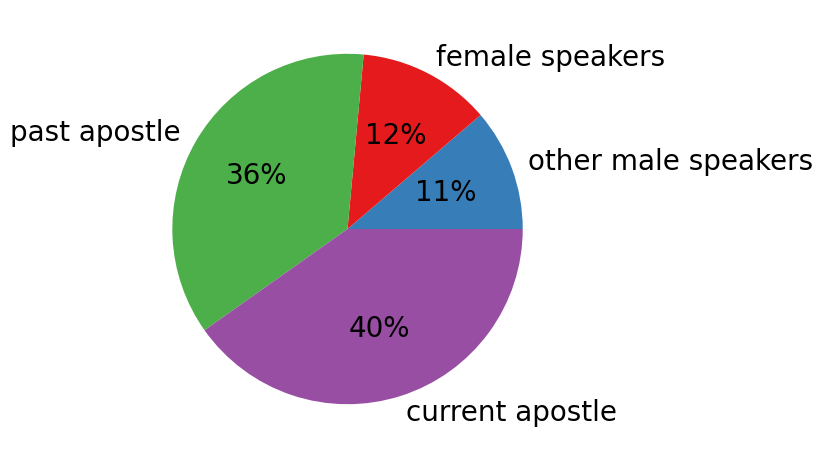

In [7]:
_ = agg_data.groupby('role')['count'].sum().sort_values().plot.pie(figsize=(6,6), ylabel='', autopct='%1.f%%')

The top 10 most prolific individual speakers about the proclamation are shown in the chart below. It is perhaps not particularly surprising that Dallin H. Oaks has the most total references, as he is believed to be the primary author of the document, despite no author being officially credited. Oaks and the late M. Russell Ballard are also outliers in the total number of talks in which they mention it, 13 and 10 respectively. These repeated returns to the same theme in talks over a long period of time suggest that those two speakers above all were the most dedicated to talking about it.

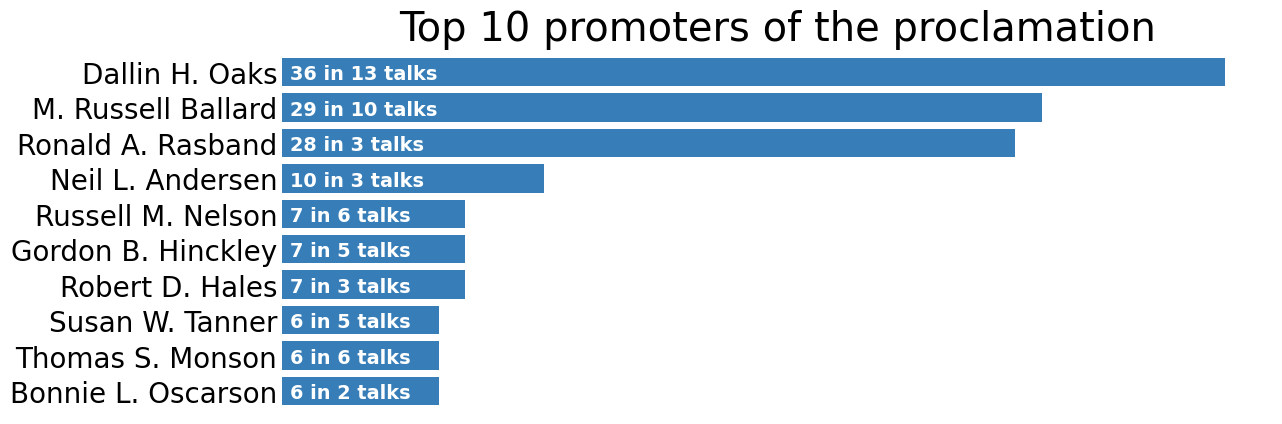

In [8]:
def bar_with_values(df, title=None):
    fig, ax = pl.subplots(figsize=((12, len(df)/2)))
    df_r = df[::-1]

    ax = df_r['count'].plot.barh(legend=False, ylabel='', width=0.8, grid=False, title=title)
    ax.xaxis.set_visible(False)
    for spine in ax.spines.values():
        spine.set_visible(False)

    for idx, row in enumerate(df_r.iterrows()):
        name, data = row
        if data["count"]:
            if data['count']==1:
                note_str = 1
            elif data['count']==3:
                note_str = f'{data["count"]} in {data["talks"]}'
            else:
                note_str = f'{data["count"]} in {data["talks"]} talks'
            #note_str = f'{data["count"]} in {data["talks"]} talks' if data["count"]>1 else '1'
            clr = 'white' #if data["count"]>3 else 'black'
            xpos = 0.3 #3.2 if data["count"]>=3 else 1.2
            ax.annotate(note_str, (xpos, idx-0.05), size='x-small', va='center', fontweight='bold', color=clr)
    ax.tick_params(axis='y', which='both', left=False, top=False)
    ax.set_facecolor('none')

#(agg_data_nz['count']/agg_data_nz['count'].sum()*100).round(1).sort_values(ascending=False)[:10].to_frame('fraction (%)')

bar_with_values(agg_data.sort_values('count', ascending=False)[:10], 'Top 10 promoters of the proclamation')

Because some apostles past and present have clearly been big promoters of the proclamation, it is instructive to see how much each of the current apostles have spoken about the proclamation. This is relevant given ongoing speculation about whether or not the church would ever move to officially canonize the document. As of this writing, a new apostle has not been named in the wake of the death of President Nelson, so there are currently 14 living apostles. The chart below illustrates the past of referring to the proclamation in history in all of their talks (including talks given before they were an apostle). Only the 3 most senior (Oaks, Holland, and Eyring) were apostles when the document was originally published.

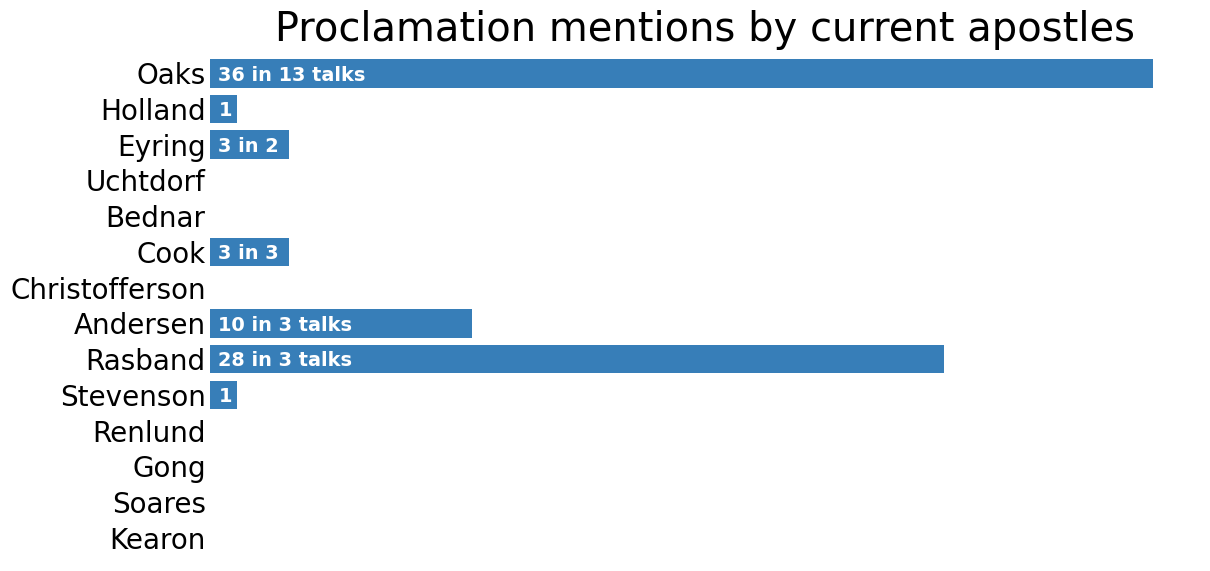

In [9]:
# join with apostle_data to get seniority order
cur_apostle_counts = apostle_data[apostle_data['dod'].isna()][['name']].merge(
    agg_data.loc[agg_data['role']=='current apostle', ['talks', 'count']],
    left_on='name', right_on='author', how='left').fillna(0).set_index('name').astype(int)

cur_apostle_counts.set_index(cur_apostle_counts.index.str.split(' ').str[-1], inplace=True)

bar_with_values(cur_apostle_counts, 'Proclamation mentions by current apostles')

The differences across the group are quite striking. The apostles seem to fall into three distinct categories. There is a contingent of proclamation boosters (Oaks, Andersen, Rasband) who speak of it regularly, a group who have occasionally made reference to it (Holland, Eyring, Cook, Stevenson), and a group who have never once mentioned it (Uchtdorf, Bednar, Christofferson, Renlund, Gong, Soares, Kearon). The silent group includes the 4 most junior apostles. This is important because it gives us a hint about the future.
# Implications
Based on the succession scheme and the fact that the three most senior apostles are all getting quite old or suffering health problems, it may not be long before either Uchdorf or Bednar (or both, in turn) become president of the church. In that future era, not only will there be no apostles left who were involved in the document's creation, but the president of the church will have never spoken of it in general conference. In addition, the incoming younger generation of apostles seem to show little interest in preaching on the subject in general conference. So, the long term future is likely one where the proclamation fades in importance as a subject for general conference talks. There has been much speculation about the possibility of the text being officially canonized, but the patterns illustrated here suggest that the likelihood of canonization is steadily decreasing over time.

In [10]:
# Setup show/hide source code box
from IPython.display import HTML

HTML('''<script>
code_show=true; 
function code_toggle() {
 if (code_show){
 $('div.input').hide();
 } else {
 $('div.input').show();
 }
 code_show = !code_show
} 
$( document ).ready(code_toggle);
</script>
<form action="javascript:code_toggle()">
<input type="submit" value="show/hide source code"></form>''')